In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import glob
glob.glob(r'individual_stocks_5yr/*csv')

['individual_stocks_5yr\\AAL_data.csv',
 'individual_stocks_5yr\\AAPL_data.csv',
 'individual_stocks_5yr\\AAP_data.csv',
 'individual_stocks_5yr\\ABBV_data.csv',
 'individual_stocks_5yr\\ABC_data.csv',
 'individual_stocks_5yr\\ABT_data.csv',
 'individual_stocks_5yr\\ACN_data.csv',
 'individual_stocks_5yr\\ADBE_data.csv',
 'individual_stocks_5yr\\ADI_data.csv',
 'individual_stocks_5yr\\ADM_data.csv',
 'individual_stocks_5yr\\ADP_data.csv',
 'individual_stocks_5yr\\ADSK_data.csv',
 'individual_stocks_5yr\\ADS_data.csv',
 'individual_stocks_5yr\\AEE_data.csv',
 'individual_stocks_5yr\\AEP_data.csv',
 'individual_stocks_5yr\\AES_data.csv',
 'individual_stocks_5yr\\AET_data.csv',
 'individual_stocks_5yr\\AFL_data.csv',
 'individual_stocks_5yr\\AGN_data.csv',
 'individual_stocks_5yr\\AIG_data.csv',
 'individual_stocks_5yr\\AIV_data.csv',
 'individual_stocks_5yr\\AIZ_data.csv',
 'individual_stocks_5yr\\AJG_data.csv',
 'individual_stocks_5yr\\AKAM_data.csv',
 'individual_stocks_5yr\\ALB_data.c

In [3]:
len(glob.glob(r'individual_stocks_5yr/*csv'))

509

In [4]:
company_list=[
    r'individual_stocks_5yr/AMZN_data.csv',
    r'individual_stocks_5yr/AAPL_data.csv',
    r'individual_stocks_5yr/GOOG_data.csv',
    r'individual_stocks_5yr/MSFT_data.csv'
]

In [5]:
all_data=pd.DataFrame()
df_list=[]
for file in company_list:

    curr_df=pd.read_csv(file)
    df_list.append(curr_df)

all_data=pd.concat(df_list,ignore_index=True)

In [6]:
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN
1,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN
2,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN
3,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN
4,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN


In [7]:
all_data.shape

(4752, 7)

In [8]:
all_data['Name'].unique()

<StringArray>
['AMZN', 'AAPL', 'GOOG', 'MSFT']
Length: 4, dtype: str

In [9]:
all_data.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [10]:
all_data.dtypes

date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
Name          str
dtype: object

In [11]:
all_data['date']=pd.to_datetime(all_data['date'])
all_data['date']

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
4747   2018-02-01
4748   2018-02-02
4749   2018-02-05
4750   2018-02-06
4751   2018-02-07
Name: date, Length: 4752, dtype: datetime64[us]

In [12]:
company_list = all_data['Name'].unique()
company_list

<StringArray>
['AMZN', 'AAPL', 'GOOG', 'MSFT']
Length: 4, dtype: str

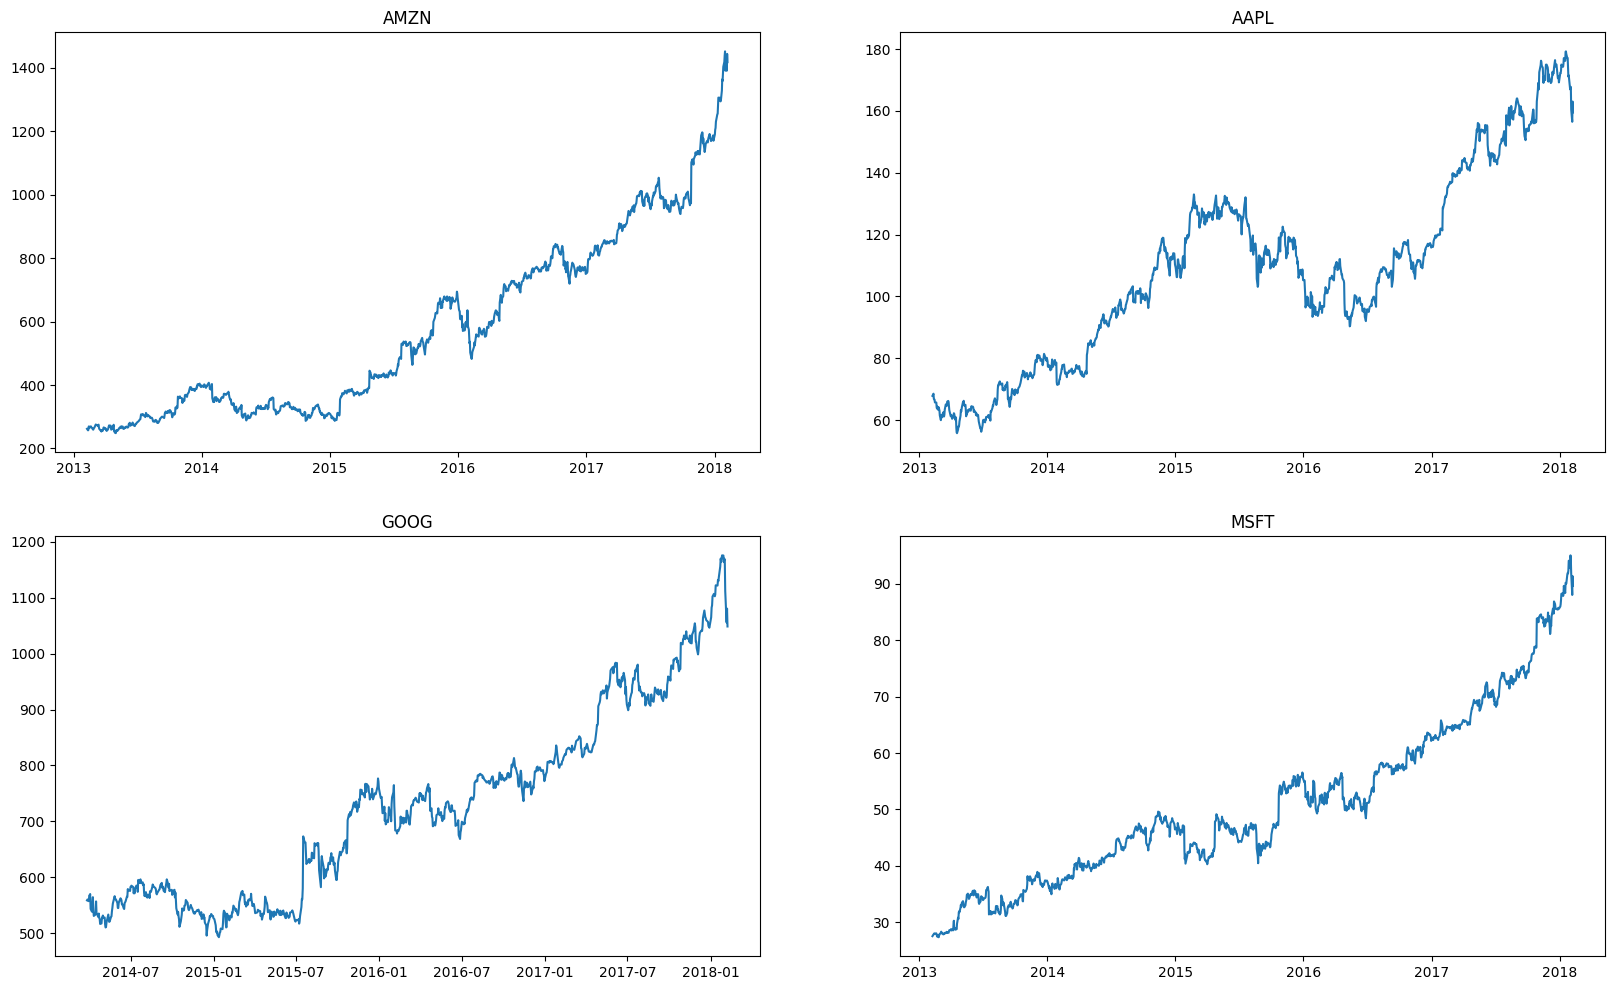

In [13]:
plt.figure(figsize=(20,12))

for index , company in enumerate(company_list , 1):
    plt.subplot(2 , 2 , index) ## creating subplot for each stock
    filter1 = all_data['Name']==company
    df = all_data[filter1]
    plt.plot(df['date'] , df['close']) ## plotting "date" vs "close"
    plt.title(company)

In [14]:
all_data.duplicated().sum()

np.int64(0)

In [15]:
all_data[all_data["volume"]<=0]

,date,open,high,low,close,volume,Name


In [16]:
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN
1,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN
2,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN
3,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN
4,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN


In [17]:
all_data=all_data.sort_values(["Name","date"])

In [18]:
all_data.head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [19]:
all_data['daily_return']=all_data.groupby('Name')['close'].pct_change()


In [20]:
risk=all_data.groupby('Name')['daily_return'].std()

In [21]:
risk

Name
AAPL    0.014593
AMZN    0.018235
GOOG    0.014069
MSFT    0.014210
Name: daily_return, dtype: float64

In [22]:
safest_stock=risk.idxmin()
safest_stock

'GOOG'

In [23]:
all_data['cumulative_return']=(1+all_data['daily_return']).groupby(all_data['Name']).cumprod()

In [24]:
final_returns=all_data.groupby('Name')["cumulative_return"].last()
final_returns

Name
AAPL    2.351218
AMZN    5.408589
GOOG    1.877628
MSFT    3.252632
Name: cumulative_return, dtype: float64

In [25]:
best_stock=final_returns.idxmax()

In [26]:
best_stock

'AMZN'

Text(0.5, 0, 'Stock')

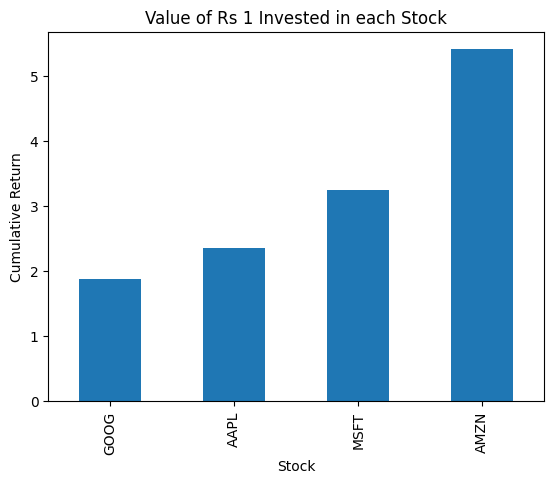

In [27]:
final_returns.sort_values().plot(kind="bar")
plt.title("Value of Rs 1 Invested in each Stock")
plt.ylabel("Cumulative Return")
plt.xlabel("Stock")

In [28]:
investment=100000

In [29]:
df_best=all_data[all_data['Name']==best_stock]
df_best

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
0,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN,NaN,NaN
1,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN,-0.018095,0.981905
2,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN,0.005793,0.987593
3,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN,0.041631,1.028708
4,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN,-0.000854,1.027830
...,...,...,...,...,...,...,...,...,...
1254,2018-02-01,1445.00,1459.88,1385.140,1390.00,9113808,AMZN,-0.041967,5.306356
1255,2018-02-02,1477.39,1498.00,1414.000,1429.95,11125722,AMZN,0.028741,5.458866
1256,2018-02-05,1402.62,1458.98,1320.720,1390.00,11494985,AMZN,-0.027938,5.306356
1257,2018-02-06,1361.46,1443.99,1351.790,1442.84,11066819,AMZN,0.038014,5.508074


In [30]:
df_best['investment_value']=df_best['cumulative_return']*investment
df_best

,date,open,high,low,close,volume,Name,daily_return,cumulative_return,investment_value
0,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN,NaN,NaN,NaN
1,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN,-0.018095,0.981905,98190.494369
2,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN,0.005793,0.987593,98759.305211
3,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN,0.041631,1.028708,102870.776866
4,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN,-0.000854,1.027830,102782.973850
...,...,...,...,...,...,...,...,...,...,...
1254,2018-02-01,1445.00,1459.88,1385.140,1390.00,9113808,AMZN,-0.041967,5.306356,530635.617484
1255,2018-02-02,1477.39,1498.00,1414.000,1429.95,11125722,AMZN,0.028741,5.458866,545886.619584
1256,2018-02-05,1402.62,1458.98,1320.720,1390.00,11494985,AMZN,-0.027938,5.306356,530635.617484
1257,2018-02-06,1361.46,1443.99,1351.790,1442.84,11066819,AMZN,0.038014,5.508074,550807.405994


In [31]:
df_best["investment_value"].tail(1).values[0]

np.float64(540858.9425462884)

In [32]:
df_best.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return', 'investment_value'],
      dtype='str')

In [33]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

In [34]:
import plotly.express as px
fig=px.line(df_best,
        x="date",
        y="investment_value",
        title=f"1 Million Investment Growth-{best_stock}",
        labels={
            'investment_value':"Portfolio Value"
        })
fig.show()

In [35]:
all_data[all_data['Name']=="AAPL"].nsmallest(5,'daily_return')

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
1502,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,AAPL,-0.079927,1.066361
2005,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,AAPL,-0.065707,1.376775
2068,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,AAPL,-0.062578,1.441620
1897,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,AAPL,-0.061163,1.558636
1305,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,AAPL,-0.054993,0.848036


In [36]:
worst_days = all_data.groupby('Name')\
    .apply(lambda x: x.nsmallest(5, 'daily_return'))\
    .reset_index()

In [37]:
worst_days

,Name,level_1,date,open,high,low,close,volume,daily_return,cumulative_return
0,AAPL,1502,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,-0.079927,1.066361
1,AAPL,2005,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,-0.065707,1.376775
2,AAPL,2068,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,-0.062578,1.441620
3,AAPL,1897,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,-0.061163,1.558636
4,AAPL,1305,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,-0.054993,0.848036
5,AMZN,246,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,-0.109972,1.369307
6,AMZN,304,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,-0.098828,1.159878
7,AMZN,367,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,-0.096484,1.236915
8,AMZN,431,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,-0.083403,1.095858
9,AMZN,748,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,-0.076100,2.240886


In [38]:
worst_days[['Name','date','daily_return']]

,Name,date,daily_return
0,AAPL,2014-01-28,-0.079927
1,AAPL,2016-01-27,-0.065707
2,AAPL,2016-04-27,-0.062578
3,AAPL,2015-08-21,-0.061163
4,AAPL,2013-04-17,-0.054993
5,AMZN,2014-01-31,-0.109972
6,AMZN,2014-04-25,-0.098828
7,AMZN,2014-07-25,-0.096484
8,AMZN,2014-10-24,-0.083403
9,AMZN,2016-01-29,-0.076100


In [39]:
px.bar(
    worst_days,
    x='date',
    y='daily_return',
    color='Name',
    title='Worst Market Crash Days (Top Losses)'
)

In [40]:
px.bar(
    worst_days,
    x='date',
    y='daily_return',
    color='Name',
    title='Worst Market Crash Days (Top Losses)'
)

In [41]:
worst_days["crash_label"] = worst_days["Name"] + " | " + worst_days["date"].dt.strftime("%Y-%m-%d")

In [42]:
worst_days

,Name,level_1,date,open,high,low,close,volume,daily_return,cumulative_return,crash_label
0,AAPL,1502,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,-0.079927,1.066361,AAPL | 2014-01-28
1,AAPL,2005,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,-0.065707,1.376775,AAPL | 2016-01-27
2,AAPL,2068,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,-0.062578,1.441620,AAPL | 2016-04-27
3,AAPL,1897,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,-0.061163,1.558636,AAPL | 2015-08-21
4,AAPL,1305,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,-0.054993,0.848036,AAPL | 2013-04-17
5,AMZN,246,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,-0.109972,1.369307,AMZN | 2014-01-31
6,AMZN,304,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,-0.098828,1.159878,AMZN | 2014-04-25
7,AMZN,367,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,-0.096484,1.236915,AMZN | 2014-07-25
8,AMZN,431,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,-0.083403,1.095858,AMZN | 2014-10-24
9,AMZN,748,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,-0.076100,2.240886,AMZN | 2016-01-29


In [45]:
fig=px.bar(
    worst_days,
    x='crash_label',
    y='daily_return',
    color='Name',
    title='Worst Market Crash Days (Top Losses)',
    labels={
        "daily_return": "daily return(loss)"
    }
)
fig.add_hline(y=0)
fig.show()

In [47]:
all_data["MA20"]=all_data.groupby('Name')["close"].transform(lambda x : x.rolling(20).mean())

In [48]:
all_data["MA50"]=all_data.groupby('Name')["close"].transform(lambda x : x.rolling(50).mean())

In [50]:
all_data.head(25)

,date,open,high,low,close,volume,Name,daily_return,cumulative_return,MA20,MA50
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN,NaN,NaN,NaN
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,0.010422,1.010422,NaN,NaN
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-0.025067,0.985095,NaN,NaN
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.001903,0.983220,NaN,NaN
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.000899,0.982336,NaN,NaN
1264,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL,-0.013780,0.968799,NaN,NaN
1265,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL,-0.000370,0.968441,NaN,NaN
1266,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL,-0.024218,0.944988,NaN,NaN
1267,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL,-0.006216,0.939114,NaN,NaN
1268,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,0.010649,0.949114,NaN,NaN


In [51]:
df_stock=all_data[all_data["Name"]=="AAPL"]

In [52]:
df_stock.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return', 'MA20', 'MA50'],
      dtype='str')

In [53]:
fig=px.line(df_stock,
            x='date',
            y=['close','MA20','MA50'],
            title="AAPL price with Moving AVG"
           )
fig.show()

In [54]:
all_data["month_name"]=all_data["date"].dt.month_name()

In [55]:
monthly_returns=all_data.groupby(['Name','month_name'])["daily_return"].mean().reset_index()

In [56]:
monthly_returns

,Name,month_name,daily_return
0,AAPL,April,-0.000335
1,AAPL,August,0.001834
2,AAPL,December,-0.001343
3,AAPL,February,0.001532
4,AAPL,January,-0.000770
5,AAPL,July,0.002413
6,AAPL,June,-0.002175
7,AAPL,March,0.001537
8,AAPL,May,0.002444
9,AAPL,November,0.001438


In [57]:
monthly_returns.columns

Index(['Name', 'month_name', 'daily_return'], dtype='str')

In [59]:
fig=px.bar(monthly_returns,
           x="month_name",
           y="daily_return",
           color="Name",
           barmode="group",
           title="Average Monthly Returns by Stock"   
)
fig.show()